# Aplicación 1: Optimización bajo restricción de riesgo

**Objetivo:** Diseñar el portafolio de mayor rendimiento esperado sujeto a un límite de riesgo.

**Instrucciones:**

- Generen al menos 30 combinaciones de pesos (que sumen 1).

- Simulen entre 5,000 y 10,000 rendimientos para cada combinación.

- Calculen para cada portafolio:

    - Rendimiento promedio.

    - Desviación estándar.

    - VaR 95%.

- Impongan la restricción:

    - VaR 95% ≥ –5%.

    - Identifiquen el portafolio con mayor rendimiento esperado que cumpla la restricción.

- Construyan:

    - Scatter plot riesgo (desviación o VaR) vs rendimiento esperado.

    - Histograma del portafolio elegido.

- Respondan:

    - ¿Cuántos portafolios cumplen la restricción?

    - ¿Cuánto rendimiento se sacrifica por controlar riesgo?

Entrega
En repositorio

In [1]:
import pandas as pd 
import numpy as np 
import yfinance as yf 
import matplotlib.pyplot as plt
import datetime as dt

In [2]:
# Descargamos los datos del portafolio
tickers = ['PLTR', 'GLD', 'TSLA', 'JNJ']
end = dt.datetime.today()
start = end - dt.timedelta(days=365*3)

data = yf.download(tickers, start=start, end=end)['Close']
returns = data.pct_change().dropna()

[*********************100%***********************]  4 of 4 completed


In [3]:
# Parámetros de la Simulación
n_sim = 10000        # Simularemos 10,000 rendimientos por combinación
n_portafolios = 500  # Generaremos 500 combinaciones 
n_days = 15

In [4]:

mu = returns.mean()
cov = returns.cov()

# Simulación Monte Carlo (Vectorizada para mayor eficiencia)
np.random.seed(42)
# Generamos escenarios simulando rendimientos diarios y los acumulamos a 15 días
sim_returns = np.zeros((n_sim, len(tickers)))

for i in range(n_sim):
    daily_ret = np.random.multivariate_normal(mu, cov, n_days)
    cum_ret = np.prod(1 + daily_ret, axis=0) - 1  # Retorno acumulado de los 15 días
    sim_returns[i] = cum_ret

In [5]:
# Generación y Evaluación de Portafolios
resultados = []
pesos_lista = []

for i in range(n_portafolios):
    # Generar pesos aleatorios que sumen 1
    w = np.random.random(len(tickers))
    w /= np.sum(w)
    pesos_lista.append(w)
    
    # Rendimientos simulados del portafolio
    port_ret = sim_returns @ w
    
    # Calcular métricas requeridas
    mean_ret = np.mean(port_ret)
    std_ret = np.std(port_ret)
    var_95 = np.percentile(port_ret, 5) # VaR 95% empírico
    
    resultados.append({
        'Rendimiento_Promedio': mean_ret,
        'Desviacion_Estandar': std_ret,
        'VaR_95': var_95
    })

df_res = pd.DataFrame(resultados)
df_res.head()

,Rendimiento_Promedio,Desviacion_Estandar,VaR_95
0,0.027202,0.054666,-0.057926
1,0.023431,0.070604,-0.084297
2,0.039843,0.101783,-0.115779
3,0.035297,0.082348,-0.090517
4,0.031771,0.074493,-0.083067


In [6]:
# Imposición de la restricción: VaR 95% >= -5% (o >= -0.05)
df_res['Cumple_Restriccion'] = df_res['VaR_95'] >= -0.05

# Identificar el portafolio de máximo rendimiento global
best_overall_idx = df_res['Rendimiento_Promedio'].idxmax()
best_overall = df_res.loc[best_overall_idx]

# Identificar el portafolio de máximo rendimiento QUE CUMPLE la restricción
valid_ports = df_res[df_res['Cumple_Restriccion']]

if not valid_ports.empty:
    best_valid_idx = valid_ports['Rendimiento_Promedio'].idxmax()
    best_valid = valid_ports.loc[best_valid_idx]
    best_valid_w = pesos_lista[best_valid_idx]
    
    # Cálculo del rendimiento sacrificado
    sacrificio = best_overall['Rendimiento_Promedio'] - best_valid['Rendimiento_Promedio']
else:
    best_valid = None
    best_valid_w = None
    sacrificio = 0


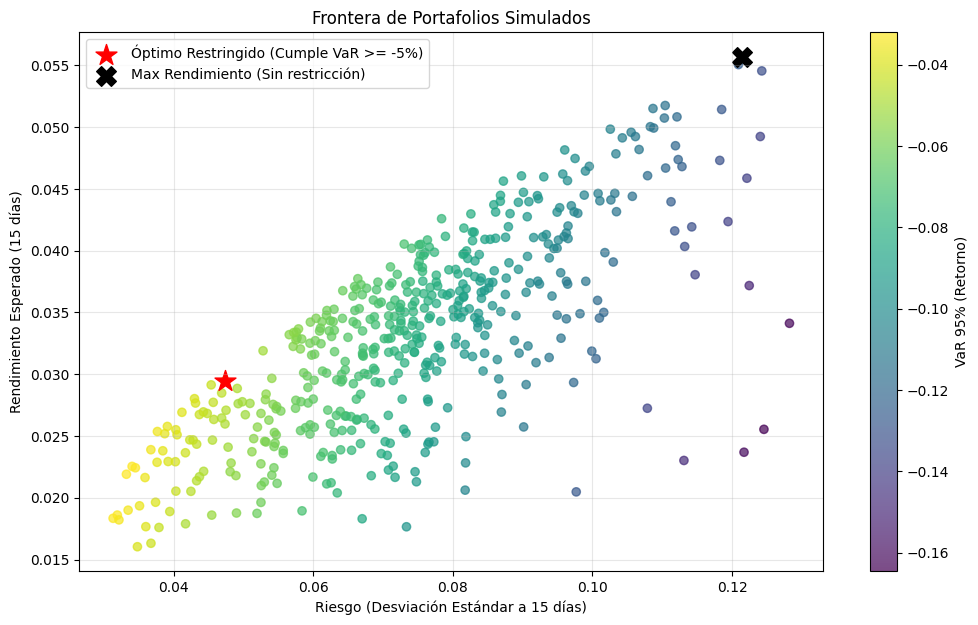

In [7]:
# Visualización Gráfico 1: Scatter plot (Riesgo vs Rendimiento)
plt.figure(figsize=(12, 7))
plt.scatter(df_res['Desviacion_Estandar'], df_res['Rendimiento_Promedio'], 
            c=df_res['VaR_95'], cmap='viridis', alpha=0.7)
plt.colorbar(label='VaR 95% (Retorno)')

if not valid_ports.empty:
    plt.scatter(best_valid['Desviacion_Estandar'], best_valid['Rendimiento_Promedio'], 
                color='red', marker='*', s=250, label='Óptimo Restringido (Cumple VaR >= -5%)')

plt.scatter(best_overall['Desviacion_Estandar'], best_overall['Rendimiento_Promedio'], 
            color='black', marker='X', s=200, label='Max Rendimiento (Sin restricción)')

plt.xlabel('Riesgo (Desviación Estándar a 15 días)')
plt.ylabel('Rendimiento Esperado (15 días)')
plt.title('Frontera de Portafolios Simulados')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

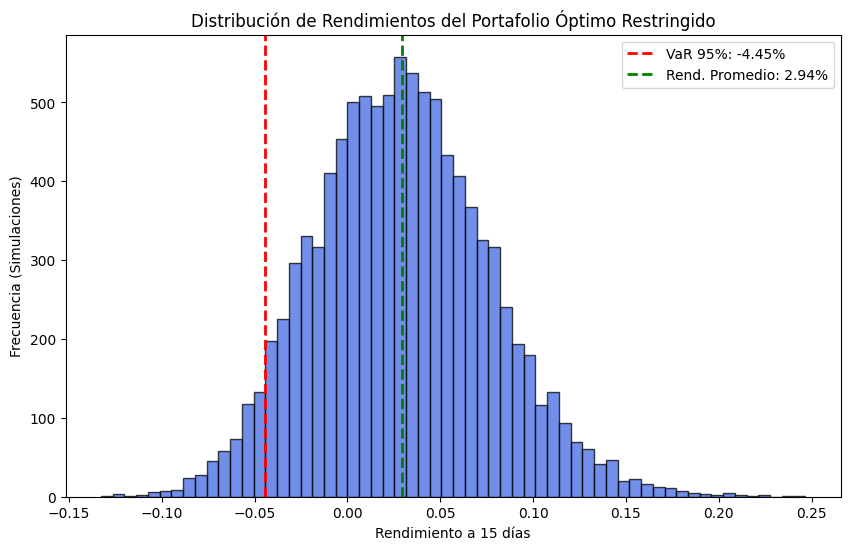

In [8]:
# Gráfico 2: Histograma del portafolio elegido 
if best_valid is not None:
    best_port_ret = sim_returns @ best_valid_w
    plt.figure(figsize=(10, 6))
    plt.hist(best_port_ret, bins=60, alpha=0.75, color='royalblue', edgecolor='black')
    plt.axvline(best_valid['VaR_95'], color='red', linestyle='dashed', linewidth=2, 
                label=f"VaR 95%: {best_valid['VaR_95']*100:.2f}%")
    plt.axvline(best_valid['Rendimiento_Promedio'], color='green', linestyle='dashed', linewidth=2, 
                label=f"Rend. Promedio: {best_valid['Rendimiento_Promedio']*100:.2f}%")
    plt.title('Distribución de Rendimientos del Portafolio Óptimo Restringido')
    plt.xlabel('Rendimiento a 15 días')
    plt.ylabel('Frecuencia (Simulaciones)')
    plt.legend()
    plt.show()

In [9]:
# Respuestas solicitadas
print("="*60)
print("RESULTADOS DE LA OPTIMIZACIÓN")
print("="*60)
print(f"Total de portafolios simulados: {n_portafolios}")
print(f"-> Portafolios que cumplen la restricción (VaR >= -5%): {len(valid_ports)}")

if not valid_ports.empty:
    print(f"\n-> ¿Cuánto rendimiento se sacrifica por controlar el riesgo?")
    print(f"   Rendimiento del mejor absoluto: {best_overall['Rendimiento_Promedio']*100:.2f}%")
    print(f"   Rendimiento del mejor restringido: {best_valid['Rendimiento_Promedio']*100:.2f}%")
    print(f"   SACRIFICIO TOTAL: {sacrificio*100:.3f}% (puntos porcentuales)")
    
    print("\nComposición del Portafolio Óptimo Restringido:")
    for stock, weight in zip(tickers, best_valid_w):
        print(f"  {stock}: {weight*100:.2f}%")
else:
    print("\nNingún portafolio logró cumplir con la restricción de VaR >= -5%.")
    print("Sugerencia: Revisa los activos o la restricción de riesgo de tu cartera.")

RESULTADOS DE LA OPTIMIZACIÓN
Total de portafolios simulados: 500
-> Portafolios que cumplen la restricción (VaR >= -5%): 51

-> ¿Cuánto rendimiento se sacrifica por controlar el riesgo?
   Rendimiento del mejor absoluto: 5.57%
   Rendimiento del mejor restringido: 2.94%
   SACRIFICIO TOTAL: 2.625% (puntos porcentuales)

Composición del Portafolio Óptimo Restringido:
  PLTR: 30.54%
  GLD: 45.46%
  TSLA: 23.34%
  JNJ: 0.66%


# Aplicación 2: Escenarios macroeconómicos

**Objetivo:** Explorar cómo cambia el comportamiento del portafolio bajo distintos contextos económicos.

**Instrucciones**

- Definan tres escenarios:

    - Base: usar los rendimientos originales.

    - Alcista: aumentar la media en +0.001.

    - Bajista: disminuir la media en –0.001.

- Simulen al menos 10,000 trayectorias para cada escenario.

- Calculen para cada escenario:

- Rendimiento promedio.

- Desviación estándar.

- Probabilidad de pérdida.

- VaR 95%.

- Construyan:

    - Histogramas comparativos de las distribuciones.

    - Gráfico comparativo de medias y desviaciones estándar.

- Analicen:

    - ¿En qué escenario la probabilidad de pérdida es mayor?

    - ¿Cuál presenta mayor dispersión de resultados?

    - ¿Cambian de manera relevante las métricas de riesgo extremo?



In [10]:
# 1. Configuración de pesos y parámetros
pesos = np.array([0.3, 0.1, 0.4, 0.2])  
n_sim = 10000
n_days = 15

In [11]:
# 2. Definición de los 3 escenarios macroeconómicos
escenarios = {
    'Base': mu,
    'Alcista': mu + 0.001,
    'Bajista': mu - 0.001
}

# Diccionarios para guardar resultados y datos para gráficas
resultados = {}
simulaciones_hist = {}

np.random.seed(42)

In [12]:
# 3. Simulación Monte Carlo por cada escenario
for nombre, media_escenario in escenarios.items():

    sim_returns = np.zeros((n_sim, len(tickers)))
    
    for i in range(n_sim):
        daily_ret = np.random.multivariate_normal(media_escenario, cov, n_days)
        cum_ret = np.prod(1 + daily_ret, axis=0) - 1 # Retorno a 15 días
        sim_returns[i] = cum_ret
        
    # Calcular el rendimiento del portafolio con los pesos fijos
    port_ret = sim_returns @ pesos
    simulaciones_hist[nombre] = port_ret # Guardar para el histograma
    
    # Calcular las métricas solicitadas
    rend_promedio = np.mean(port_ret)
    desv_estandar = np.std(port_ret)
    prob_perdida = np.mean(port_ret < 0) # Frecuencia donde rendimiento es negativo
    var_95 = np.percentile(port_ret, 5)  # VaR 95% empírico
    
    resultados[nombre] = {
        'Rendimiento Promedio': rend_promedio,
        'Desviación Estándar': desv_estandar,
        'Probabilidad de Pérdida': prob_perdida,
        'VaR 95%': var_95
    }

# Convertir los resultados a un DataFrame de fácil lectura
df_resultados = pd.DataFrame(resultados).T
print("MÉTRICAS POR ESCENARIO:")
print("="*65)
print(df_resultados.map(lambda x: f"{x*100:.2f}%")) # porcentaje
print("="*65)

MÉTRICAS POR ESCENARIO:
        Rendimiento Promedio Desviación Estándar Probabilidad de Pérdida  \
Base                   4.19%               8.76%                  33.46%   
Alcista                5.70%               8.72%                  26.38%   
Bajista                2.46%               8.54%                  40.75%   

         VaR 95%  
Base      -9.06%  
Alcista   -7.73%  
Bajista  -10.80%  


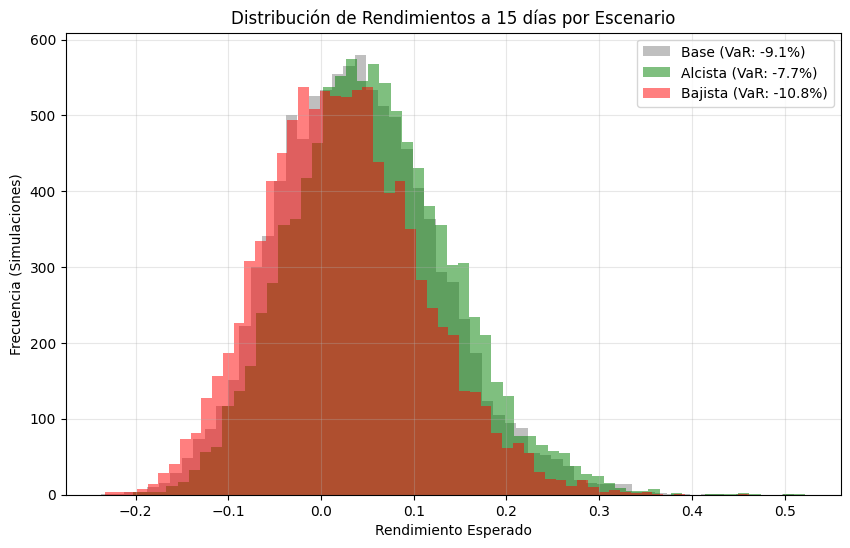

In [13]:
# 4. Visualización: Histogramas Comparativos
plt.figure(figsize=(10, 6))
colores = {'Base': 'gray', 'Alcista': 'green', 'Bajista': 'red'}

for nombre, port_ret in simulaciones_hist.items():
    plt.hist(port_ret, bins=60, alpha=0.5, color=colores[nombre], 
             label=f"{nombre} (VaR: {resultados[nombre]['VaR 95%']*100:.1f}%)")

plt.title('Distribución de Rendimientos a 15 días por Escenario')
plt.xlabel('Rendimiento Esperado')
plt.ylabel('Frecuencia (Simulaciones)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

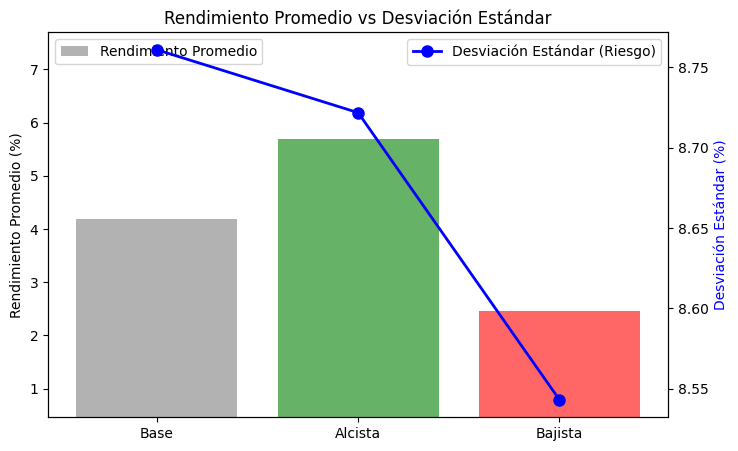

In [14]:
# Visualización: Gráfico Comparativo (Medias vs Desviación)
fig, ax1 = plt.subplots(figsize=(8, 5))

# Eje izquierdo para la media
ax1.bar(df_resultados.index, df_resultados['Rendimiento Promedio']*100, 
        color=['gray', 'green', 'red'], alpha=0.6, label='Rendimiento Promedio')
ax1.set_ylabel('Rendimiento Promedio (%)')
ax1.set_ylim([min(df_resultados['Rendimiento Promedio']*100) - 2, 
              max(df_resultados['Rendimiento Promedio']*100) + 2])

# Eje derecho para la Desviación Estándar (Riesgo)
ax2 = ax1.twinx()
ax2.plot(df_resultados.index, df_resultados['Desviación Estándar']*100, 
         color='blue', marker='o', linewidth=2, markersize=8, label='Desviación Estándar (Riesgo)')
ax2.set_ylabel('Desviación Estándar (%)', color='blue')

plt.title('Rendimiento Promedio vs Desviación Estándar')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.show()

## Respuestas:

1. **¿En qué escenario la probabilidad de pérdida es mayor?** 

*Respuesta:* En el escenario bajista la probabilidad de pérdida es mayor

2. **¿Cuál presenta mayor dispersión de resultados?**

*Respuesta:* Sorprendentemente, ninguno presenta una dispersión significativamente mayor; la dispersión es prácticamente idéntica en los tres escenarios.

3. **¿Cambian de manera relevante las métricas de riesgo extremo?**

*Respuesta:* Sí, las métricas de riesgo extremo (como el VaR 95%) sí cambian de manera relevante.